# Questão 2.2


## 2. 
Usando o esquema numérico de Crank-Nicolson resolve o problema mixto para a equa ̧c ̃ao paraxial no dominio $Ω = {(x, z)|x ∈ [0, 3000], z ∈ [0, 500]}$ de forma seguinte:

- a equação:

$$iu_x + bu_{zz} + Vu = 0$$

- os coeficientes:

$$b
 = 5$$ 

$$V (z) = exp(iz/4) exp [-\frac{
(z − 250)2}
{1500}] $$


- as condiçoes de contorno:
 $$u(x, 0) = u(x, L) =
  0$$
onde $$L = 
500$$ ,
- a condi ̧c ̃ao inicial:

$$u(0, z) = u_0(z) = exp [-\frac{ 
(z − 250)^2}
{30000}] $$
.

Dica: pode usar passos ∆x = 5, ∆z = 1.

Primeiramente vamos definir o stencil 

In [33]:
! pip install numpy scipy matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2

In [34]:

import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spilu
from matplotlib import pyplot as plt


x_max = 3000
z_max = 500

delta_x = 5 
delta_z = 1
n_x = int(x_max/delta_x) # Número de pontos do stenccil em x
n_z = int(z_max/delta_z) # Número de pontos do stenccil em y
x = np.linspace(0, x_max, n_x)
z = np.linspace(0, z_max, n_z)

X, Z = np.meshgrid(x,z)



def V(z):
    return np.exp(-(z - 250)**2 / 30000)

def condicao_inicial(z):
    return np.exp(1j * z / 4) * np.exp(-((z - 250)**2) / 1500)

b = 5



No nosso esquema, temos uma recorrencia da seguinte forma:

$$A r_{n+1}  = B r_{n}$$

Onde $r_n$ representa o vetor:


$$r_n = 
\begin{pmatrix} 
u(x_n, z_0) = u_{n,0}\\
u(x_n, z_1) = u_{n,1}\\
\vdots \\ 
u(x_n, z_i) = u_{n,i}\\
\vdots \\
\end{pmatrix}
$$


$$x_n = x_0 + n*\Delta x$$
$$z_i = z_0 + i*\Delta z $$


Como o potencial não depende de x, e como a matriz de propragação $ A^{-1} C $ ( sabemos que $A$ tem inversa) apresentam dependencia de $x$ ( e consequentemente $n$ ) apenas devido ao potencial, então podemos concluir que a matriz é  a mesma para todo $n$. Portanto, basta inverter a e calcular o produto $A^{-1}C$ uma vez


Em nosso esquema:

$$C_{00}=A_{00} = 1$$
e 
$$
C_{0k}=A_{0k} =0 $$ 
para $k\not= 0$ 

$$A_{(J-1)(J-1)}= A_{(J-1)(J-1)} = 1 $$
e
$$C_{k(J-1)} =A_{k(J-1)} = 0$$
para $k\not= J-1$

Onde $J$ é número de pontos $z$ da grade

Daí 

$$A_{jj} = \frac{i}{\Delta x} + \frac{V_j}{2} - \frac{b}{\Delta z ^2 }$$

para $j$ entre $1$ e $J-2$

Já a diagonal de baixo é: 
$$A_{(j+1)j} = \frac{b}{2\Delta z ^2}$$
para $j$ entre $0$ e $J-3$. 

A de cima é:
$$A_{(j-1)j} = \frac{b}{2\Delta z ^2}$$
para $j$ entre $2$ e $J-1$

e

$$C_{jj} = \frac{i}{\Delta x} - \frac{V_j}{2} + \frac{b}{\Delta z ^2 }$$

Já a diagonal de baixo é: 
$$C_{(j+1)j} = -\frac{b}{2\Delta z ^2}$$
para $j$ entre $0$ e $J-3$. 

A de cima é:
$$C_{(j-1)j} = -\frac{b}{2\Delta z ^2}$$
para $j$ entre $2$ e $J-1$





In [36]:
V_j = V(z)



def fazer_matriz(J, V_j, dx, dz, b):
    
    # V_j é um vetor 
    diag_A = np.zeros(J, dtype=complex)
    diag_C = np.zeros(J, dtype=complex)

    diag_A[0] = 1.0
    diag_C[0] = 1.0

    diag_A[-1] = 1.0
    diag_C[-1] = 1.0

    diag_A[1:-1] = 1j/dx + V_j[1:-1]/2 - b/dz**2
    diag_C[1:-1] = 1j/dx - V_j[1:-1]/2 + b/dz**2

    diag_baixo_A = np.ones(J-1,dtype=complex)*b/(2*dz**2)
    diag_baixo_A[-1] = 0
    diag_cima_A = np.ones(J-1,dtype=complex)* b/(2*dz**2)
    diag_cima_A[0] = 0

    diag_baixo_C = -np.ones(J-1,dtype=complex)*b/(2*dz**2)
    diag_baixo_C[-1] = 0
    diag_cima_C = -np.ones(J-1,dtype=complex)* b/(2*dz**2)
    diag_cima_C[0] = 0

    A = diags([diag_baixo_A, diag_A, diag_cima_A], [-1,0,1], format = "csc")
    C = diags([diag_baixo_C, diag_C, diag_cima_C], [-1,0,1], format = "csc")
    A_info = {
    "matriz_esparsa": A,
    "diag_cima": diag_cima_A,
    "diag": diag_A,
    "diag_baixo": diag_baixo_A
    }

    C_info = {
        "matriz_esparsa": C,
        "diag_cima": diag_cima_C,
        "diag": diag_C,
        "diag_baixo": diag_baixo_C
    }

    return A_info, C_info

A_info,C_info = fazer_matriz(J= n_z, V_j=V_j, dx = delta_x, dz = delta_z, b= b)

    




Aqui conseguimos então gerar as duas matrizes, elas são salvas de forma esparsa.

Para reolver o problema vamos implementar o algoritimo de thomas para resolver 

In [37]:
def resolver_thomas(cima, baixo, meio, y):
    #Ax = y
    
    J = len(meio)
    d = meio.astype(complex).copy()
    c = cima.astype(complex).copy()
    b = baixo.astype(complex).copy()
    yf = y.astype(complex).copy()

    for j in range(1, J):
        m = b[j-1] / d[j-1]
        d[j] = d[j] - m * c[j-1]
        yf[j] = yf[j] - m * yf[j-1]
    #Voltando 
    x = np.zeros(J, dtype=complex)
    x[-1] = yf[-1] / d[-1]

    for j in range(J-2, -1, -1):
        x[j] = (yf[j] - c[j] * x[j+1]) / d[j]

    return x




Por fim vamos apenas aplicar o algoritimo

In [38]:
r_0 = condicao_inicial(z=z)

def operar(A_info,C, r_n):
    A_cima = A_info["diag_cima"]
    A_baixo = A_info["diag_baixo"]
    A_meio = A_info["diag"]
    y = C@r_n
    r_n_mais_1 = resolver_thomas(cima =A_cima, baixo=A_baixo,meio=A_meio, y=y )
    return r_n_mais_1

# Determinar um x_n
def x_n(A_info,C, r0, n):
    r_atual = r0.astype(complex).copy()
    if n < 0 or n >= n_x:
        return None
    if n == 0:
        return r0
    for _ in range(n):
        r_atual = operar(A_info=A_info, C=C,r_n= r_atual)

    return r_atual

x_1 = x_n(A_info=A_info, C= C_info["matriz_esparsa"], r0= r_0, n=1 )



Pode ser útil determinar uma função para observar toda a evolução 



In [44]:
def evolucao_completa(A_info, C, r0, n_x):

    J = len(r0)
    R = np.zeros((n_x, J), dtype=complex)
    R[0] = r0.astype(complex)
    
    r_atual = R[0].copy()
    
    for n in range(1,n_x):
        r_atual = operar(A_info=A_info, C=C, r_n=r_atual)
        R[n] = r_atual
    
    return R

R = evolucao_completa(A_info=A_info, C= C_info["matriz_esparsa"], r0=r_0, n_x=n_x)
np.shape(R)
np.abs(R)

array([[8.02410471e-19, 1.11985252e-18, 1.56078721e-18, ...,
        1.56078721e-18, 1.11985252e-18, 8.02410471e-19],
       [8.02410471e-19, 4.97250866e-19, 2.19932619e-19, ...,
        6.94129495e-14, 3.51224204e-14, 8.02410471e-19],
       [8.02410471e-19, 9.59175401e-19, 1.11558257e-18, ...,
        1.67881123e-12, 8.49254931e-13, 8.02410471e-19],
       ...,
       [8.02410471e-19, 5.47960878e-07, 1.09431500e-06, ...,
        3.44486543e-07, 1.70992260e-07, 8.02410471e-19],
       [8.02410471e-19, 4.93559955e-07, 9.85439171e-07, ...,
        6.20458588e-07, 3.09684412e-07, 8.02410471e-19],
       [8.02410471e-19, 4.34744769e-07, 8.68146951e-07, ...,
        7.75738444e-07, 3.87680205e-07, 8.02410471e-19]], shape=(600, 500))

Vamos usar um mapa de calor para verificar $||u(x,y)||^2$

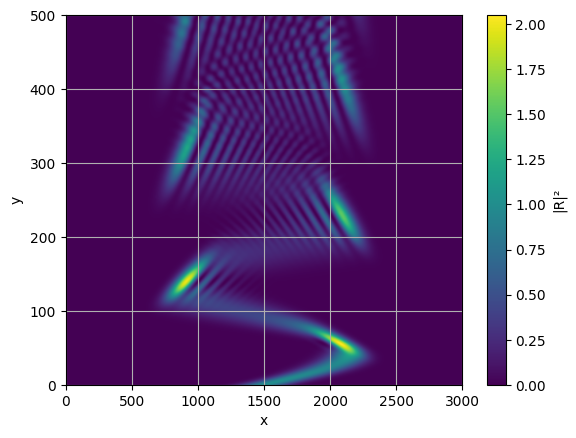

In [68]:
plt.imshow(np.abs(R)**2,
           aspect='auto',
           origin='lower',
           extent=[0, n_x*delta_x, 0, n_z*delta_z])

plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.colorbar(label="|R|²")
plt.show()



Podemos também verificar a função densidade de probabilidade para cada secção vertical. 

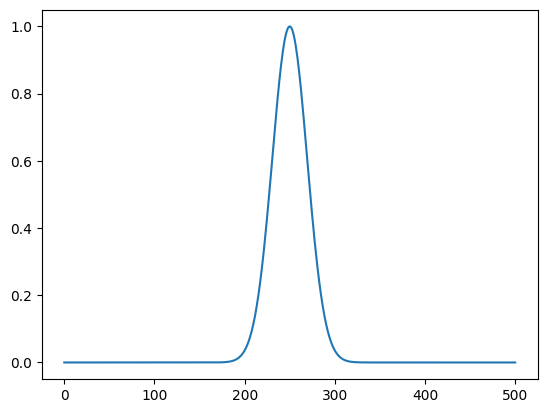

In [93]:
#Lembrar de divitir por 5 o número no gráfico 
condicao_inicial_modulo = np.abs(R[0,:])**2
plt.plot(z, condicao_inicial_modulo)
plt.show()


Além disso, o método deve manter a norma da probabilidade para cada x constante conforme a propagação na direção x. Podemos então analisar essa norma.

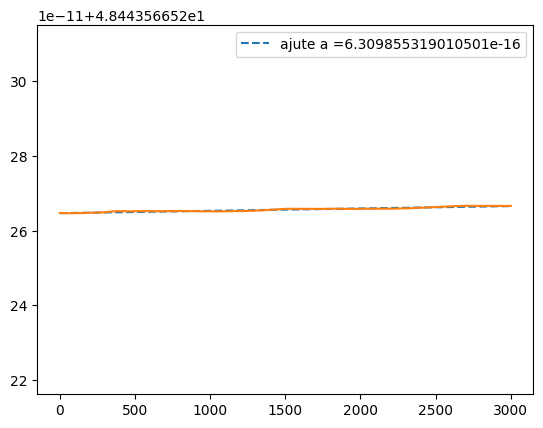

In [87]:
norma = np.sum(np.abs(R)**2, axis=1)
a,b  = np.polyfit(x, norma, 1)
plt.plot(x, a*x+b,linestyle= "--", label= f"ajute a ={a}")
plt.plot(x,norma)

plt.legend()
plt.show()


Percebemos que o processo númerico está, pelo menos, preservando a norma a cada operação.

In [ ]:
"""
b = np.ones(99)
c = np.ones(98)

a = np.ones(10)*2

b = np.ones(9)*0
c = np.ones(8)*0
A = diags([c,b,a,b,c], [-2,-1,0,1,2], shape=(10,10), format='dia')

print(A.toarray())
np.zeros((10,10))
print(A@a)
"""

[[2. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 2.]]
[4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]


In [17]:
[i for i in range(1)]

[0]